# Introductory Remarks on Random Walk
### Prof: Juan Ignacio Vázquez Broquá
#### Date: April 23, 2024
---

# Preliminary Review

__The random walk__

In the warm summer months of 1905, Karl Pearson was perplexed by the problem of the random walk. He appealed to the readers of Nature for a solution as the problem was - as it still is - “of considerable interest”.

The random walk, also known as the drunkard’s walk, is central to probability theory and still occupies the mathematical mind today. Among Pearson’s respondents was Lord Rayleigh, whose assistance led Pearson to conclude that:

_“the most probable place to find a drunken man who is at all capable of keeping on his feet is somewhere near his starting point!”_.

### White Noise:

**Definition**: White noise is a stochastic process that consists of a series of independent and identically distributed random values. These values are typically drawn from a normal distribution with a mean of zero and a standard deviation of one. White noise has a constant power spectral density across all frequencies, giving it a uniform appearance on a frequency plot. It is a useful tool in signal processing, time series analysis, and modeling errors in statistical models due to its statistical properties.

Key characteristics of white noise:
- **Mean**: Typically zero (for a zero-mean white noise).
- **Variance**: Constant, often set to one.
- **Independence**: Each value is independent of the others.
- **Identically distributed**: Each value is drawn from the same distribution.

### Random Walk:

**Definition**: A random walk is a stochastic process that describes a path consisting of a series of random steps. It can occur in one or more dimensions (e.g., one-dimensional, two-dimensional). A random walk can be defined as follows:

- **Starting point**: Usually begins at a fixed point (e.g., position zero).
- **Steps**: The process takes random steps either forward or backward (in one dimension) or in any direction (in higher dimensions).
- **Accumulation**: The position at each step is the accumulation of all previous steps.

Random walks can be described mathematically by the equation:
$$
\ X_n = X_{n-1} + \epsilon_n \
$$
Where:
- $X_n$ is the position at step $n$.

- $X_{n-1}$ is the position at the previous step.

- $\epsilon_n$ is a random step (often drawn from a distribution such as a normal distribution or a discrete distribution like {-1, 1}).

Applications of random walk include finance (e.g., modeling stock prices), physics, ecology, and other fields that require the modeling of random movements or behaviors.


# Simulation

In [8]:
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib notebook

def e(u=0, s=1 ,n=1):
    '''
    White Noise Generator
    '''
    return np.random.normal(u, s,n)


def rw(y0 = 100, C=0, E=(0,1) ,n=1000):
    '''
    Random Walk Generator
    '''

    ts_ls = []
    ts_ls.append(y0)
    for i in range(n):
        Y_t = ts_ls[i] + e(E[0],E[1]) + C
        ts_ls.append(Y_t[0])
    return ts_ls

## White Noise

Setting $\epsilon$ as a normally distributed process __N__( $\mu = 0 , \sigma=1$ )

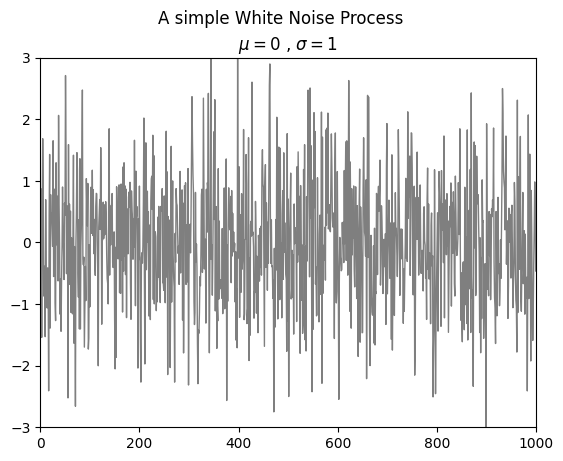

In [9]:
# 1.000 iterations of a white noise process with
plt.plot(e(n=1000), linewidth=1, alpha=0.5,color='k')
plt.ylim(-3, 3)
plt.xlim(0,1000)
plt.suptitle('A simple White Noise Process')
plt.title('$\mu = 0$ , $\sigma = 1$');

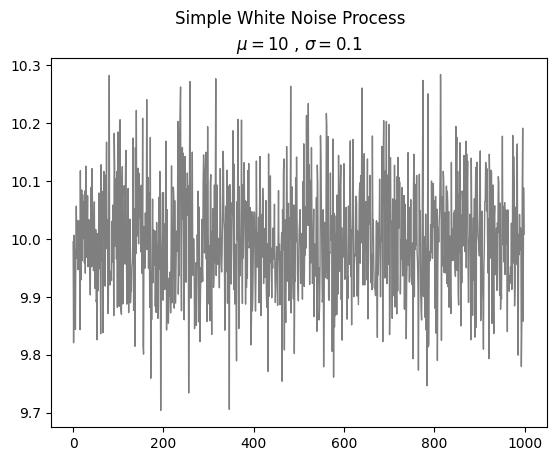

In [10]:
# 1.000 iterations of a white noise process with
plt.plot(e(n=1000,u=10,s=0.1), linewidth=1, alpha=0.5,color='k')
plt.suptitle('Simple White Noise Process');
plt.title('$\mu = 10$ , $\sigma = 0.1$');

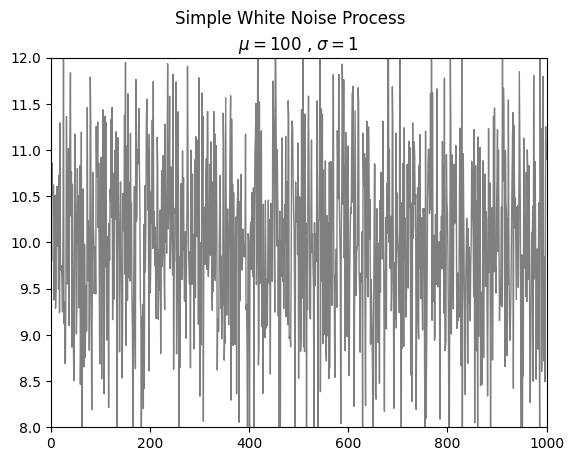

In [11]:
# 1.000 iterations of a white noise process with
plt.plot(e(n=1000,u=10,s=1), linewidth=1, alpha=0.5,color='k')
plt.ylim(8, 12)
plt.xlim(0,1000)
plt.suptitle('Simple White Noise Process');
plt.title('$\mu = 100$ , $\sigma = 1$');

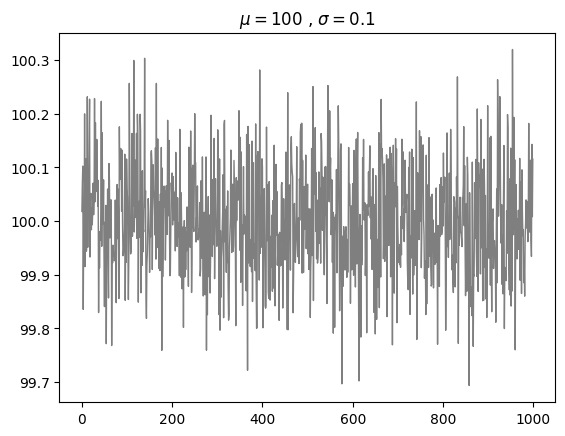

In [5]:
# 1.000 iterations of a white noise process with
# Can you visually tell any significant change in the process?
plt.plot(e(n=1000,u=100,s=0.1), linewidth=1, alpha=0.5,color='k')
plt.title('Another White Noise Process');
plt.title('$\mu = 100$ , $\sigma = 0.1$');

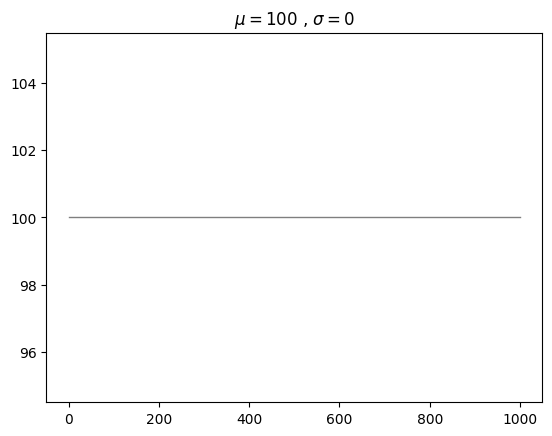

In [12]:
# 1.000 iterations of a white noise process with
# Can you visually tell any significant change in the process?
plt.plot(e(n=1000,u=100,s=0), linewidth=1, alpha=0.5,color='k')
plt.title('Another White Noise Process?');
plt.title('$\mu = 100$ , $\sigma = 0$');

We must keep in mind that in order to have a stochastic process we can always touch $\mu$ but we can't give up on $\sigma$ .

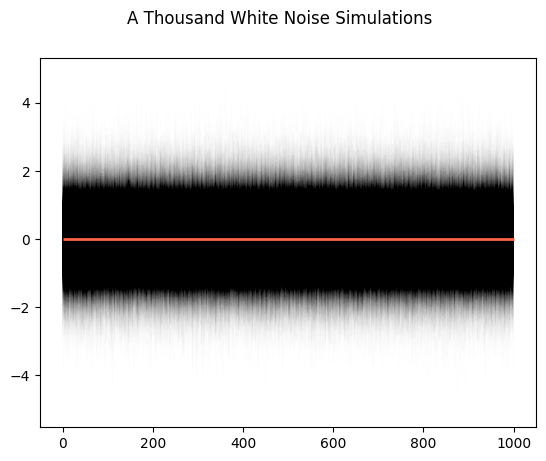

In [13]:
obs = []
for i in range(1000):
    temp = e(n=1000)
    plt.plot(temp, linewidth=1, alpha=0.005,color='k')
    obs =+ temp
plt.hlines(y = 0, xmin = 0, xmax = 1000,color='tomato',linewidth=2)
plt.suptitle('A Thousand White Noise Simulations');

(-5.0, 5.0)

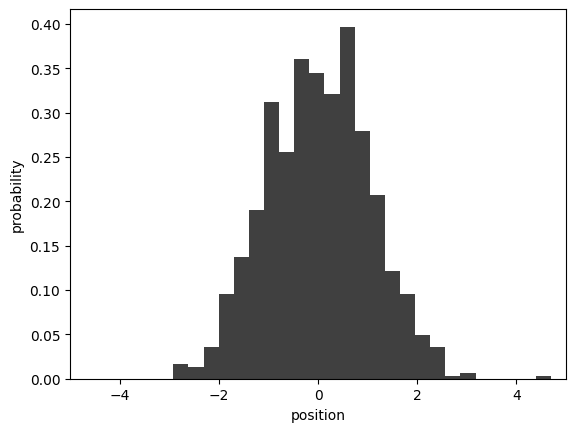

In [14]:
# the last time step, whatever that may be.
plt.hist(obs, bins=25, density=True,color='k',alpha=0.75)
plt.xlabel('position')
plt.ylabel('probability')
plt.xlim([-5, 5])

## Random Walk

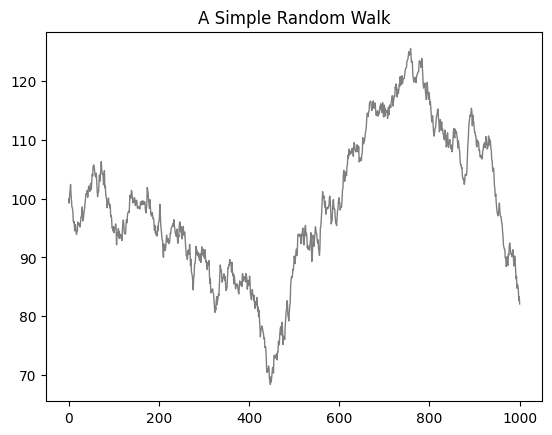

In [18]:
plt.plot(rw(),linewidth=1, alpha=0.5,color='k')
plt.title('A Simple Random Walk') ;

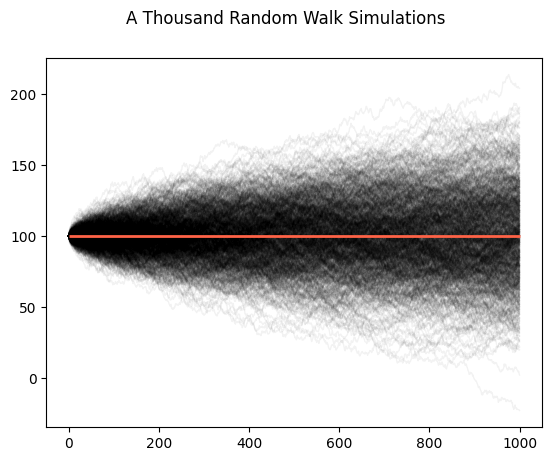

In [19]:
obs = []
for i in range(1000):
    temp = rw()
    plt.plot(temp, linewidth=1, alpha=0.05,color='k')
    obs += temp
plt.hlines(y = 100, xmin = 0, xmax = 1000,color='tomato',linewidth=2)
plt.suptitle('A Thousand Random Walk Simulations');

(0.0, 200.0)

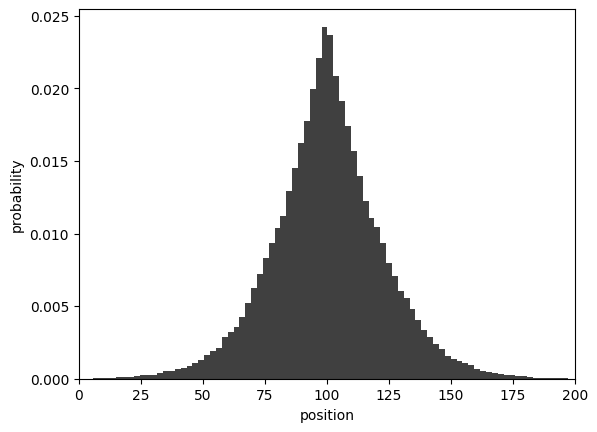

In [20]:
# the last time step, whatever that may be.
plt.hist(obs, bins=100, density=True,color='k',alpha=0.75)
plt.xlabel('position')
plt.ylabel('probability')
plt.xlim([0, 200])

# Variotions on a Random Walk

## RW and $\mu$

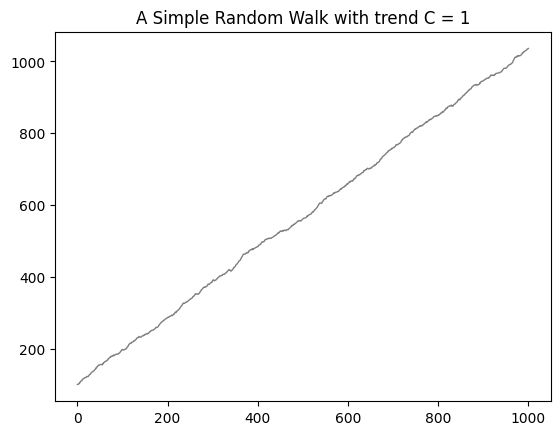

In [21]:
# Simple Random Walk
plt.plot(rw(C=1), linewidth=1, alpha=0.5,color='k')
plt.title('A Simple Random Walk with trend C = 1');

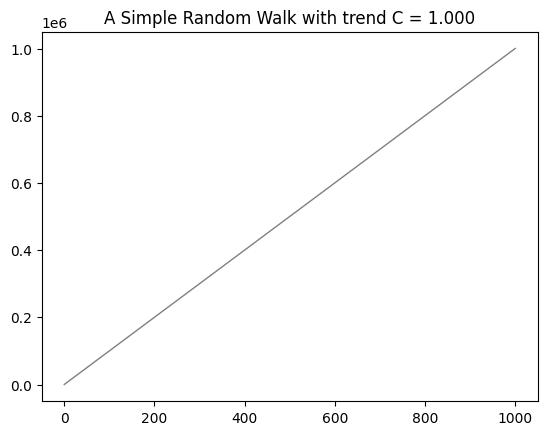

In [22]:
# Simple Random Walk
plt.plot(rw(C=1000), linewidth=1, alpha=0.5,color='k')
plt.title('A Simple Random Walk with trend C = 1.000');

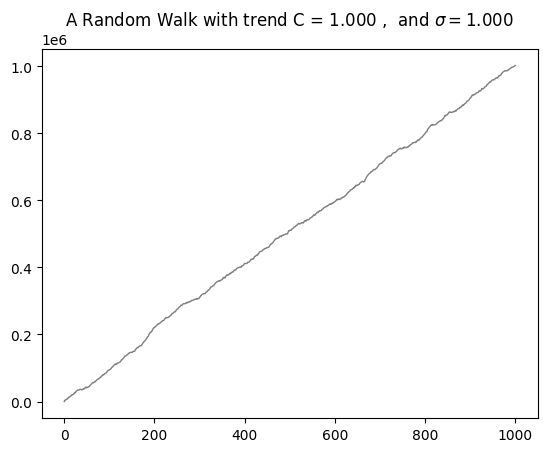

In [23]:
# Simple Random Walk
plt.plot(rw(C=1000,E=(0,1000)), linewidth=1, alpha=0.5,color='k')
plt.title('A Random Walk with trend C = 1.000 ,  and $\sigma =1.000 $ ');

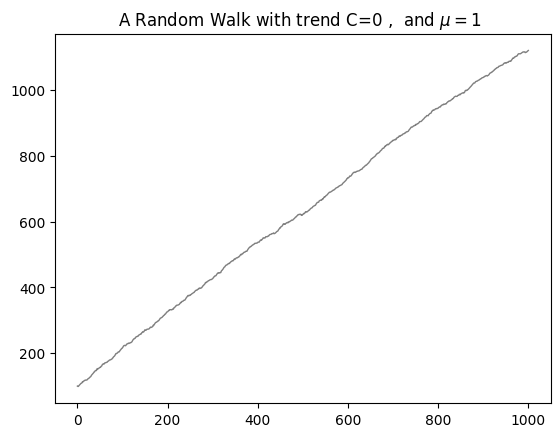

In [ ]:
# How about that?
# Any bias on mu translate in
# We can conclude that C is redundant
plt.plot(rw(C=0,E=(1,1)), linewidth=1, alpha=0.5,color='k')
plt.title('A Random Walk with trend C=0 ,  and $\mu =1 $  ');

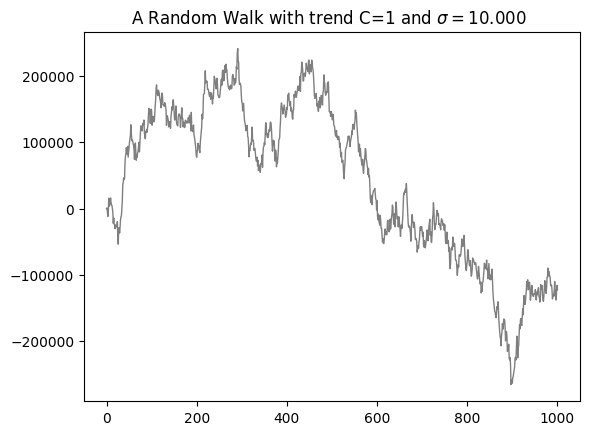

In [24]:
# How about that?
# The behavior of the RW whith a trend (C) is relative to the white noise's sigma
# it all has to do with the relationship between mu,sigma and the size of the realization(n).

plt.plot(rw(C=1,E=(0,10000)), linewidth=1, alpha=0.5,color='k')
plt.title('A Random Walk with trend C=1 and $\sigma =10.000 $  ');

## RW and $\sigma$

As we saw earlier, the presence of a trend within a random walk has to do with its $\epsilon$ 's $\mu$ , and more specifically to its relative size to  $\sigma$.

Thus, a rw is inherently determined by the value of its corresponding white noise process: $\epsilon$.

We coud say that a Random Walk process is nothing else than the cummulate process described by an underlying white noise process.

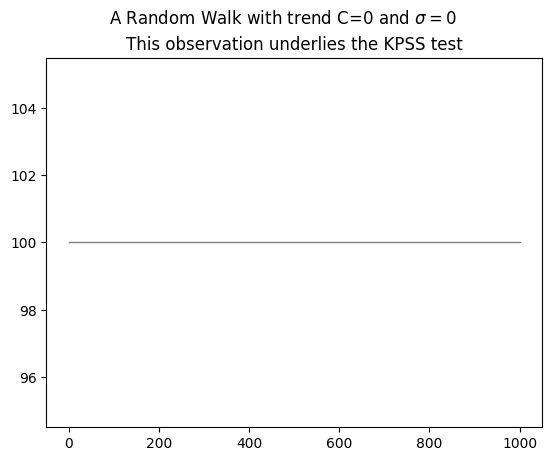

In [25]:
plt.plot(rw(C=0,E=(0,0)), linewidth=1, alpha=0.5,color='k')
plt.suptitle('A Random Walk with trend C=0 and $\sigma = 0 $  ');
plt.title('This observation underlies the KPSS test');